# Sea-Surface-Calibration scans and evaluation

This notebook contains the evaluation of the Sea-Surface-Calibration scans and their evaluation with the different water-range determination methods.

In [1]:

from lidalign.io import WindCubeScanDB
from lidalign.utils import load_template, publication_figure
load_template()
import xarray as xr

import plotly.graph_objects as go
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from lidalign.SSC import SSC

Using lidar_monitoring.mplstyle as matplotlib style template
Using lidar_monitoring.mplstyle as matplotlib style template

     __              __             __                                                         
    / _\ ___  __ _  / _\_   _ _ __ / _| __ _  ___ ___                                          
    \ \ / _ \/ _` | \ \| | | | '__| |_ / _` |/ __/ _ \                                         
    _\ \  __/ (_| | _\ \ |_| | |  |  _| (_| | (_|  __/                                         
    \__/\___|\__,_| \__/\__,_|_|  |_|  \__,_|\___\___|                                         
       ___      _ _ _               _   _                                                      
      / __\__ _| (_) |__  _ __ __ _| |_(_) ___  _ __                                           
     / /  / _` | | | '_ \| '__/ _` | __| |/ _ \| '_ \                                          
    / /__| (_| | | | |_) | | | (_| | |_| | (_) | | | |                                         
    \____/\__

In [ ]:
import pathlib 
savepath = pathlib.Path.home()  /'Figures'
savepath.mkdir(exist_ok=True)

datapath = '' 
if datapath == '':
    raise ValueError('You must download the data and put here the path to the directory (end with top level)')

time_difference_lidar_actual = pd.to_datetime('2025-05-03 10:37') - pd.to_timedelta('2h') - pd.to_datetime('2010-01-02 15:51:32') ## PC time - Lidar time - correction for UTC
time_difference_lidar_actual

Timedelta('5599 days 16:45:28')

load data and correct azimuht (only!)

## Load and correct data

In [3]:

# SSLgroup ='HelgoHarbour_ppi1' # does not work, not enough data 
# SSLgroup = 'HardTarget_25mSSL_ppi'  # few datapoints for 25m
L_rg = 50

DB = WindCubeScanDB(datapath +fr"C_SSC\{L_rg}m\\", file_structure='flat')
SSLdata = DB.get_data(returnformat = 'xarray')
for ds in SSLdata:
    ds['time'] = pd.to_datetime(ds['time']) + time_difference_lidar_actual
    if L_rg==25:
        ds = ds.sel(time = slice(pd.to_datetime('2025-05-03 10:15:00'),None))
        # print('Yes')
        # print(len(ds['time']))
        # print(len(ds['time']))
        # print(ds['time'].values[0])

Finding all files for wind_and_aerosols_data
	 --> 4 files found
	 Filtering for 2010-01-02 17:36:30+00:00 to 2026-01-12 19:04:33.170864, None 
	 --> 4 files found for given regex and time range


Reading files: 100%|██████████| 4/4 [00:00<00:00, 13.14it/s]


In [4]:
import numpy as np
def angle_offset_function(azimuth, phase, amplitude, offset):
    return np.cos(np.deg2rad(phase + azimuth))* amplitude + offset


# --------------- from hard target mapping, see other notebook --------------- #
azimuth_phase = 322
azimuth_ampl = 0.05
azimuth_offset = 41.86 + 0.38 # 0.38° repositioning offset, theodilite has been moved and not perfectly aligned with first positions

for ds in SSLdata:
    ds['azimuth'] = (ds['azimuth'] - angle_offset_function(ds['azimuth'],azimuth_phase, azimuth_ampl, azimuth_offset)) %360


### Plot and filter CNR 

Some filters are required to obtain purely valid measurement data. 

Unfortunately, due to the installation at a (busy) quay, we had to filter out ships, pedestrians and other things that blocked our measurements. In an offshore application, significantly less disturbance will be seen.

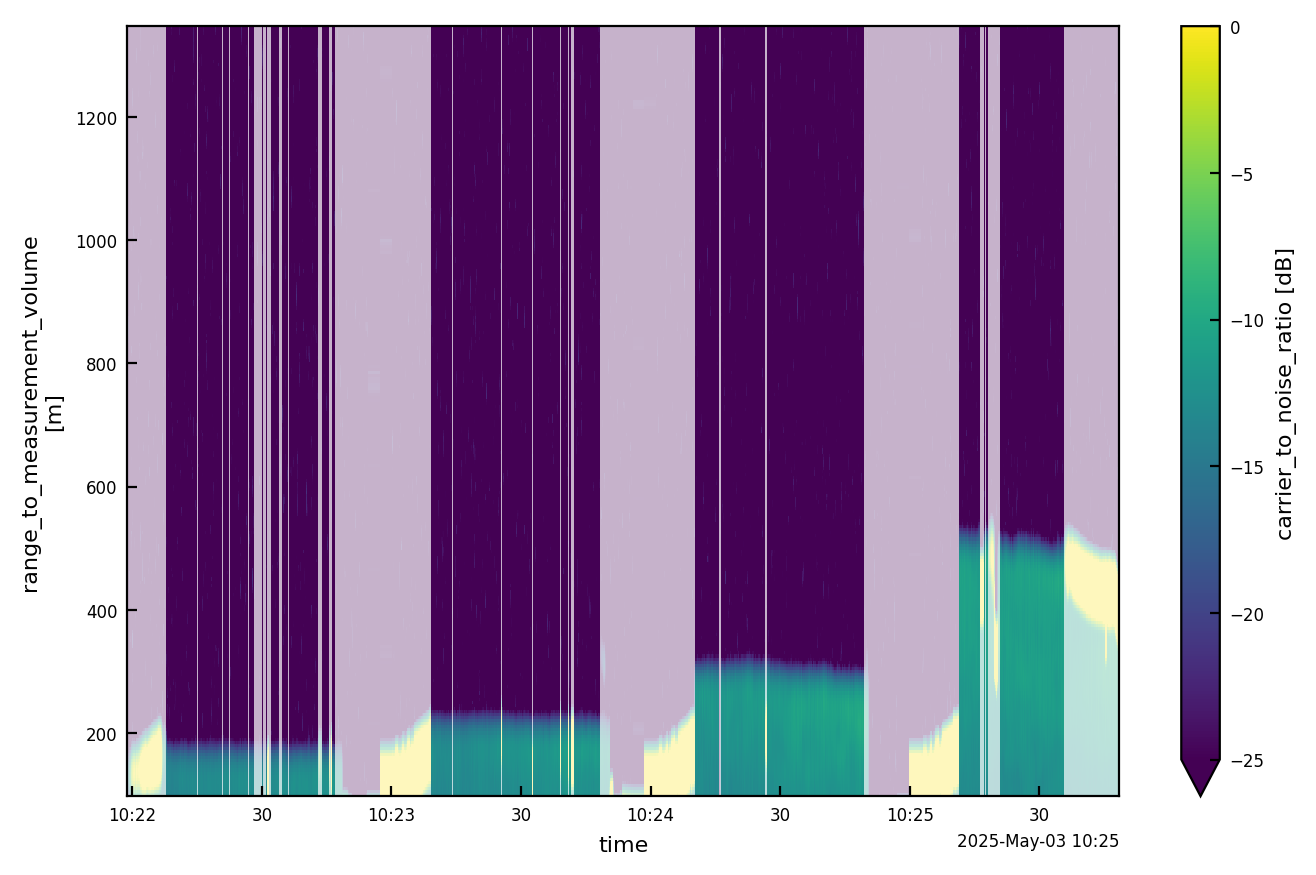

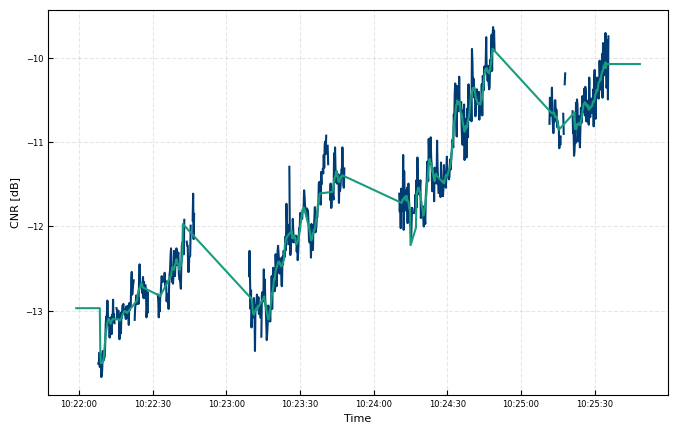

In [5]:
%matplotlib inline

combdata = xr.concat(SSLdata, dim = 'time')
fig, ax = plt.subplots(dpi = 200)
combdata['cnr'].plot(y = 'range', ax = ax, vmin = -25, vmax = 0, alpha = 0.3, add_colorbar  = False)
combdata = combdata.where((combdata['cnr'].max(dim = 'range')<-8) & # remove too high CNR
                          (combdata['cnr'].max(dim = 'range')>-20) &  # remove too low CNR
                          (combdata['cnr'].idxmax(dim = 'range')!= combdata.range[0]) & # remove if first data had max CNR
                          (combdata['azimuth']>(140-azimuth_offset)) & #  removing reflections from the dock
                          (combdata['azimuth']<(240-azimuth_offset))  & #  removing reflections from the dock
                          (~((combdata['time'] > pd.to_datetime('2025-05-03 09:55:00')) & (combdata['time'] < pd.to_datetime('2025-05-03 10:15:00'))))
                       )#  removing beginning and end of datas with bad CNR

rollmean = combdata['cnr'].max(dim = 'range').rolling(time=10, center=True).mean().interpolate_na(dim = 'time').bfill(dim = 'time').ffill(dim= 'time')

rolling_condition = np.abs(combdata['cnr'].max(dim = 'range') - rollmean) > 1 ## remove outliers 
combdata = combdata.where(~rolling_condition)

combdata['cnr'].plot(y = 'range', ax = ax, vmin = -25, vmax = 0, alpha =1)

fig, ax= plt.subplots()
ax.plot(combdata.time, combdata['cnr'].max(dim= 'range'))
ax.plot(rollmean.time, rollmean)
ax.set(ylabel = 'CNR [dB]', xlabel = 'Time')

combdata_nona = combdata.dropna(dim = 'time', how = 'all')

## Get lidar-water distances for all methods

In [6]:

## works better with CNR noise at -27 for Gra24 because it is fitted in dB scale - need to remove the unneccessary noise first
from lidalign.SSC import GaussianTruncatedPulse
waterranges_convo = SSC(combdata_nona.copy()).get_all_water_ranges(func = 'Convo',# cnr_noise_cut = -28,
pulse = GaussianTruncatedPulse(50)).distance_ds

waterranges_linsig = SSC(combdata_nona.copy()).get_all_water_ranges(func = 'LinSig', cnr_noise_cut = -28,
pulse = GaussianTruncatedPulse(50)).distance_ds

waterranges_linconvo = SSC(combdata_nona.copy()).get_all_water_ranges(func = 'LinConvo',
pulse = GaussianTruncatedPulse(50)).distance_ds

waterranges_gra = SSC(combdata_nona.copy()).get_all_water_ranges(func = 'Gra24', cnr_noise_cut = None).distance_ds

Obtaining lidar-water range: 100%|██████████| 642/642 [00:10<00:00, 61.76it/s]


with convolution water ranges:

In [7]:
waterranges_gra_raw = waterranges_gra.copy()

In [8]:
mean = waterranges_gra_raw['water_range'].rolling(time = 10, center = True).mean()
std = waterranges_gra_raw['water_range'].rolling(time = 10, center = True).std()
waterranges_gra = waterranges_gra_raw.where(((mean + 2* std) > waterranges_gra_raw['water_range']) & (mean - 2* std < waterranges_gra_raw['water_range'] ), drop = True)
waterranges_gra25 = waterranges_gra.copy()
waterranges_gra25['water_range'] = waterranges_gra25['water_range'] - 25 

#### Save to files (to use later)

In [9]:
waterranges_convo.to_netcdf('data/fitresults/waterranges_ConvoDB.nc')
waterranges_linsig.to_netcdf('data/fitresults/waterranges_LinSig.nc')
waterranges_linconvo.to_netcdf('data/fitresults/waterranges_Convo.nc')
waterranges_gra.to_netcdf('data/fitresults/waterranges_Gra24.nc')
waterranges_gra25.to_netcdf('data/fitresults/waterranges_Gra24-PV2.nc')

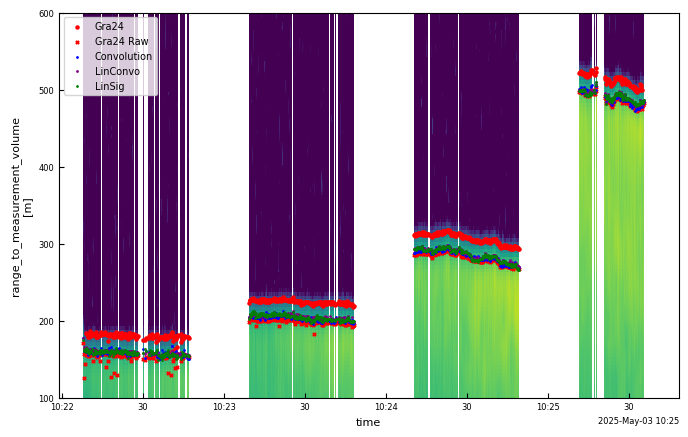

In [10]:
%matplotlib inline
fig, ax = plt.subplots()
combdata['cnr'].plot(y = 'range', ax = ax, vmin = -25, vmax = -8, alpha =1, add_colorbar  = False)
ax.scatter(waterranges_gra['time'], waterranges_gra['water_range'], label = 'Gra24', c = 'r', s =5)
ax.scatter(waterranges_gra_raw['time'], waterranges_gra_raw['water_range']-25, label = 'Gra24 Raw', c = 'r', s =5, marker = 'x')
ax.scatter(waterranges_convo['time'], waterranges_convo['water_range'], label = 'Convolution', c = 'blue', s =1)
ax.scatter(waterranges_linconvo['time'], waterranges_linconvo['water_range'], label = 'LinConvo', c = 'purple', s =1)
ax.scatter(waterranges_linsig['time'], waterranges_linsig['water_range'], label = 'LinSig', c = 'green', s =1)
ax.set(ylim = (100,600))
ax.legend(loc = 'upper left')

## Get the actual SSL  misalignment and calibration values
<div class="alert alert-block alert-warning">
<b>Attention:</b> We have to subtract the 1.66m offset in the range for all range measurements (see other notebook or following link)
</div>

[Lidar Range error from distance measurements](20_CornerScanTest_Heligoland.ipynb#Check-distance-error-against-the-wall)

we can either:
- use the data stored before (safe and reproducable)
- use the now aquired data

In [11]:
water_range_source = 'data/fitresults/' # latest version
water_range_source = 'data/fitresults/PaperResults/' # Results for Paper

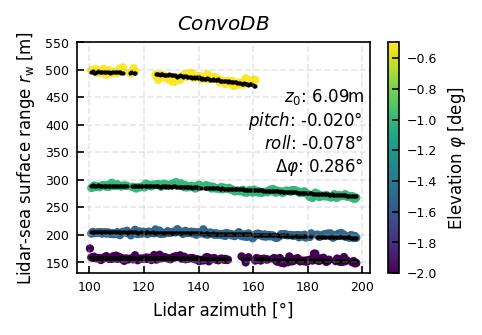

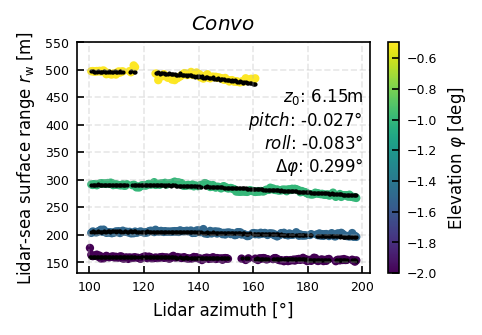

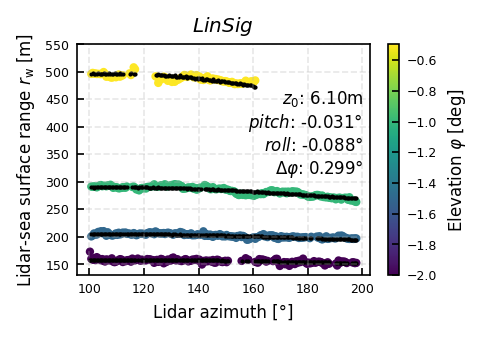

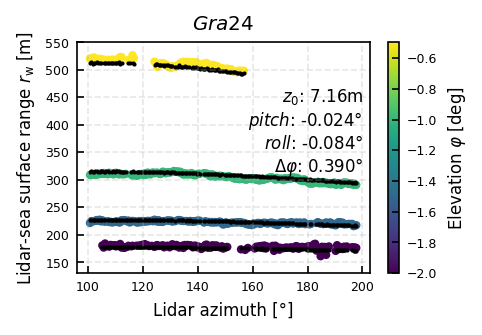

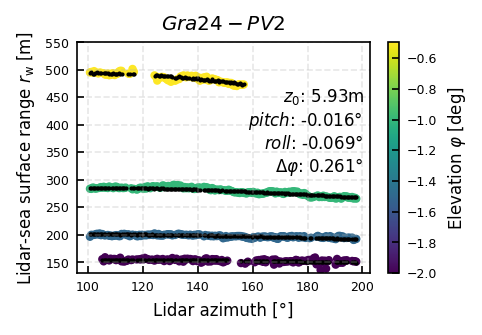

In [13]:
%matplotlib inline

for name in ['ConvoDB','Convo' ,'LinSig', 'Gra24', 'Gra24-PV2']:
    ranges = xr.load_dataset(water_range_source + f'waterranges_{name}.nc')
    fig, ax = publication_figure(1/2, dpi = 150, height = 2)
    ax.set(ylim = (130,550))
    ranges_copy = ranges.copy()
    ranges_copy['water_range'] = ranges_copy['water_range'] -1.66
    res = SSC.get_misalignment(
                ranges_copy, consider_elevation_offset=True, plot=True, print_help=False,ax = ax,
                x0 = [0.1,0.1,6.17], 
                consider_earth_curvature=True,
                reduce_errors = 'ranges',
                fit_method = 'lorentz',
                error_normalized = True,
                fixed_height = None, 
            )
    roll, pitch, height, ele_offset = res.x
    text = (
            f'\n$z_0$: {height:.2f}m'+
            f'\n$pitch$: {pitch:.3f}° '+
            f'\n$roll$: {roll:.3f}°\n'+
            r'$\Delta\varphi$'+f': {ele_offset:.3f}°'
            )
    ax.text(0.98, 0.9, text, ha = 'right', va= 'top', transform=ax.transAxes)

    ax.set(title = f'${name}$')
    ax.set(xlabel = 'Lidar azimuth [°]', ylabel = r'Lidar-sea surface range $r_{\rm w}$ [m]')
    plt.legend().remove()

    plt.savefig(savepath + f'SSC_Misalignment_{name}_{L_rg}.pdf', dpi = 300, bbox_inches = 'tight', pad_inches = 0)


## Appendix


## Earth curvature considerations
Depending on the installation height of the lidar, we cannot detect the water at each elevation angle. 

f(a) and f(b) must have different signs
No solution found, maybe you will never touch the water at this elevation -0.159°
f(a) and f(b) must have different signs
No solution found, maybe you will never touch the water at this elevation -0.158°
f(a) and f(b) must have different signs
No solution found, maybe you will never touch the water at this elevation -0.157°
f(a) and f(b) must have different signs
No solution found, maybe you will never touch the water at this elevation -0.156°
f(a) and f(b) must have different signs
No solution found, maybe you will never touch the water at this elevation -0.155°
f(a) and f(b) must have different signs
No solution found, maybe you will never touch the water at this elevation -0.154°
f(a) and f(b) must have different signs
No solution found, maybe you will never touch the water at this elevation -0.153°
f(a) and f(b) must have different signs
No solution found, maybe you will never touch the water at this elevation -0.152°
f(a) and f(b) must have 

[Text(0.5, 1.0, 'Earth Curvature Effect on Lidar Water Surface Interception\nLidar height: 20 m')]

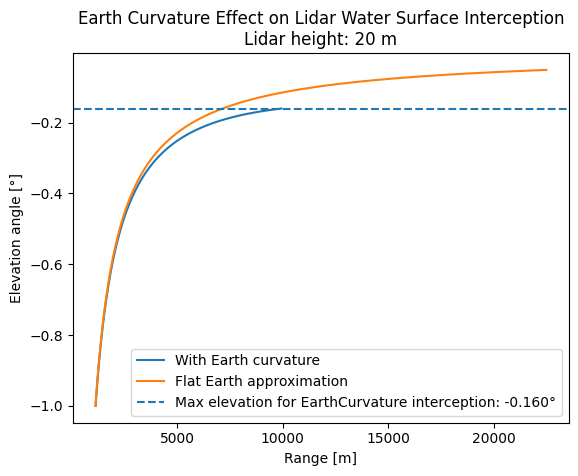

In [ ]:
from lidalign.SSL import EarthCurvature
import numpy as np
import matplotlib.pyplot as plt
h = 20
elevations = np.arange(-1,-0.050,0.001)
radii = []
flats = []
for v in elevations:
    radii.append(EarthCurvature.get_intercept_with_curvature(h, v))
    flats.append(h/np.arcsin(np.deg2rad(-v)))

fig, ax = plt.subplots()
ax.plot(radii,elevations,  label = 'With Earth curvature')
ax.plot(flats, elevations, label = 'Flat Earth approximation')
ax.set(xlabel = 'Range [m]', ylabel = 'Elevation angle [°]')
max_ele = elevations[np.nanargmax(radii)]
ax.axhline(max_ele, ls = '--', label = f'Max elevation for EarthCurvature interception: {max_ele:.3f}°')
ax.legend()
ax.set(title = "Earth Curvature Effect on Lidar Water Surface Interception\n" + f"Lidar height: {h} m")

# fig, ax = plt.subplots()
# ax.plot(np.array(radii)-np.array(flats), verts)
# ax.set(xscale= 'log')
# EarthCurvature.get_intercept_with_curvature(50, verts)

### investigate single timestamps

first guess for middle range: 160
first_guess: [200, np.float64(-31.282), np.float64(-13.158), 0.01, 0.01]
bounds: Bounds(array([ 1.0e+02, -4.0e+01, -2.3e+01,  5.0e-04, -1.5e-02]), array([ 8.e+02, -2.e+01, -3.e+00,  1.e+00,  3.e-02]))
Using fit method: LSQ


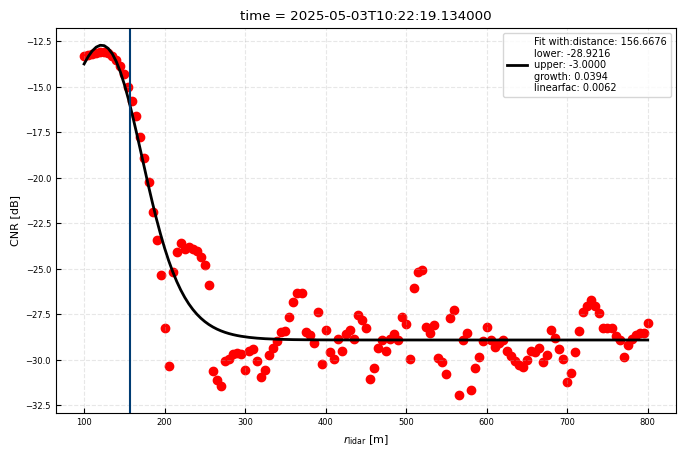

In [ ]:
from lidalign.SSL import WaterRangeDetection, inverse_sigmoid_Gra24
%matplotlib inline
t = '2025-05-03 10:22:08.12'
t = '2025-05-03 10:22:20.35'
t = '2025-05-03 10:22:19.2'
res = WaterRangeDetection(combdata.sel(time = t, method = 'nearest').sel(range = slice(None, 800)),
pulse = GaussianTruncatedPulse(50), verbose = 2).get_water_range_from_cnr(func = 'Gra24', show_plot = True, cnr_noise_cut = None, use_bounds = True, dist_guess = 200)